## CELL 1: Import Libraries

In [1]:
# Numerical computations
import numpy as np

# Data handling
import pandas as pd

# Preprocessing tools
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Random module for GA
import random

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## CELL 2: Load Dataset

In [3]:
# Load UNSW-NB15 dataset (ensure parquet is in your folder)
data = pd.read_parquet('UNSW_NB15_training-set.parquet')
# View first rows
data.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [ ]:
print(data['attack_cat'].unique())

['Normal', 'Backdoor', 'Analysis', 'Fuzzers', 'Shellcode', 'Reconnaissance', 'Exploits', 'DoS', 'Worms', 'Generic']
Categories (10, object): ['Analysis', 'Backdoor', 'DoS', 'Exploits', ..., 'Normal', 'Reconnaissance',
                          'Shellcode', 'Worms']


## CELL 3: Basic Preprocessing

In [ ]:
# Drop unnecessary columns if present
if 'id' in data.columns:
    data.drop(['id'], axis=1, inplace=True)

# Convert target column (label)
# 0 = normal, 1 = attack
y = data['label']

# Drop label from features
X = data.drop('label', axis=1)

# Encode categorical columns using a more robust check for non-numeric types
non_numeric_cols = [col for col in X.columns if not pd.api.types.is_numeric_dtype(X[col])]

for col in non_numeric_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Remove leakage-prone columns
if 'attack_cat' in X.columns:
    X = X.drop('attack_cat', axis=1)

# FIRST split (stratified)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# SECOND split (also stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

# NOW apply scaling
scaler = MinMaxScaler()

# Convert DataFrames to NumPy arrays before scaling for robustness
X_train = scaler.fit_transform(X_train.values)   # fit ONLY on training data
X_val = scaler.transform(X_val.values)           # transform validation
X_test = scaler.transform(X_test.values)         # transform test

print("Train distribution:\n", y_train.value_counts())
print("Validation distribution:\n", y_val.value_counts())
print("Test distribution:\n", y_test.value_counts())

Train distribution:
 label
1    71604
0    33600
Name: count, dtype: int64
Validation distribution:
 label
1    23868
0    11200
Name: count, dtype: int64
Test distribution:
 label
1    23869
0    11200
Name: count, dtype: int64


## CELL 4: Baseline Model (NO GA)

In [ ]:
# Function to build model
def create_model(learning_rate=0.001, neurons=32, dropout_rate=0.2):

    model = Sequential()  # initialise model

    model.add(Dense(neurons, input_dim=X_train.shape[1], activation='relu'))  # input layer

    model.add(Dropout(dropout_rate))  # reduce overfitting

    model.add(Dense(neurons, activation='relu'))  # hidden layer

    model.add(Dense(1, activation='sigmoid'))  # output layer

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## CELL 5: Train Baseline Model

In [ ]:
# Create baseline model
baseline_model = create_model()

# Train model
baseline_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    verbose=1
)

# Predictions
baseline_preds = (baseline_model.predict(X_test) > 0.5).astype("int32")

# Evaluate
print("Baseline Accuracy:", accuracy_score(y_test, baseline_preds))
print(classification_report(y_test, baseline_preds))

Epoch 1/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8924 - loss: 0.2643
Epoch 2/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9270 - loss: 0.1844
Epoch 3/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9303 - loss: 0.1722
Epoch 4/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9308 - loss: 0.1647
Epoch 5/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9315 - loss: 0.1594
Epoch 6/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9319 - loss: 0.1557
Epoch 7/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9327 - loss: 0.1517
Epoch 8/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9334 - loss: 0.1485
Epoch 9/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9332 - loss: 0.1469
Epoch 10/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9341 - loss: 0.1456
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Baseline Accuracy: 0.935470073284097
              precision    recall  f1-

## CELL 6: GA Setup (Feature + Hyperparameters)

In [ ]:
# Define parameter space
param_space = {
    "learning_rate": [0.001, 0.0005],
    "neurons": [32, 64],
    "dropout": [0.2, 0.3],
    "batch_size": [32, 64]
}

# Number of features
num_features = X_train.shape[1]

# Create individual (features + parameters)
def create_individual():

    # Feature mask (0 or 1)
    feature_mask = np.random.randint(0, 2, num_features)

    # Ensure at least one feature is selected
    if feature_mask.sum() == 0:
        feature_mask[random.randint(0, num_features-1)] = 1

    return {
        "features": feature_mask,
        "learning_rate": random.choice(param_space["learning_rate"]),
        "neurons": random.choice(param_space["neurons"]),
        "dropout": random.choice(param_space["dropout"]),
        "batch_size": random.choice(param_space["batch_size"])
    }

## CELL 7: Fitness Function

In [ ]:
def fitness(individual):

    # Select features using mask
    mask = individual["features"]

    X_tr = X_train[:, mask == 1]
    X_va = X_val[:, mask == 1]   # use validation instead of test

    # Build model
    model = Sequential()

    model.add(Dense(individual["neurons"], input_dim=X_tr.shape[1], activation='relu'))
    model.add(Dropout(individual["dropout"]))
    model.add(Dense(individual["neurons"], activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=individual["learning_rate"]),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Train quickly (low epochs for GA speed)
    model.fit(X_tr, y_train, epochs=3, batch_size=individual["batch_size"], verbose=0)

    # Predict
    preds = (model.predict(X_va) > 0.5).astype("int32") # Changed X_te to X_va

    # Return accuracy
    return accuracy_score(y_val, preds)

## CELL 8: Run Genetic Algorithm

In [ ]:
population_size = 6
generations = 3

# Initial population
population = [create_individual() for _ in range(population_size)]

for gen in range(generations):

    print("Generation:", gen+1)

    scores = [(ind, fitness(ind)) for ind in population]

    # Sort by fitness
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    print("Best Accuracy:", scores[0][1])

    # Select top individuals
    population = [ind for ind, score in scores[:3]]

    # Mutation
    while len(population) < population_size:
        parent = random.choice(population)
        child = parent.copy()

        key = random.choice(["learning_rate","neurons","dropout","batch_size"])
        child[key] = random.choice(param_space[key])

        population.append(child)

# Best solution
best = scores[0][0]
print("Best Parameters Found")

Generation: 1
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Best Accuracy: 0.926913425345044
Generation: 2
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Best Accuracy: 0.9292802555035931
Generation: 3
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Best Accuracy: 0.92913767537356
Best Parameters Found


## CELL 9: Train Hybrid Model (GA Optimised)

In [ ]:
# Apply feature mask
mask = best["features"]

X_tr = X_train[:, mask == 1]
X_te = X_test[:, mask == 1]

# Build final model
final_model = Sequential()

final_model.add(Dense(best["neurons"], input_dim=X_tr.shape[1], activation='relu'))
final_model.add(Dropout(best["dropout"]))
final_model.add(Dense(best["neurons"], activation='relu'))
final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(
    optimizer=Adam(learning_rate=best["learning_rate"]),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
final_model.fit(
    X_tr, y_train,
    epochs=10,
    batch_size=best["batch_size"],
    verbose=1
)

# Predict
preds = (final_model.predict(X_te) > 0.5).astype("int32")

Epoch 1/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9044 - loss: 0.2400
Epoch 2/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9274 - loss: 0.1706
Epoch 3/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9300 - loss: 0.1581
Epoch 4/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9312 - loss: 0.1524
Epoch 5/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9336 - loss: 0.1473
Epoch 6/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9328 - loss: 0.1454
Epoch 7/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9337 - loss: 0.1429
Epoch 8/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9349 - loss: 0.1418
Epoch 9/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9349 - loss: 0.1408
Epoch 10/10
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9350 - loss: 0.1389
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


## CELL 10: Evaluation Metrics

In [ ]:
# Select features
X_test_selected = X_test[:, best["features"] == 1]

# Predict on TEST set
preds = (final_model.predict(X_test_selected) > 0.5).astype("int32")

# Evaluate
print("Hybrid Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step
Hybrid Accuracy: 0.9339017365764636
              precision    recall  f1-score   support

           0       0.93      0.85      0.89     11200
           1       0.93      0.97      0.95     23869

    accuracy                           0.93     35069
   macro avg       0.93      0.91      0.92     35069
weighted avg       0.93      0.93      0.93     35069



## CELL 11: Confusion Matrix

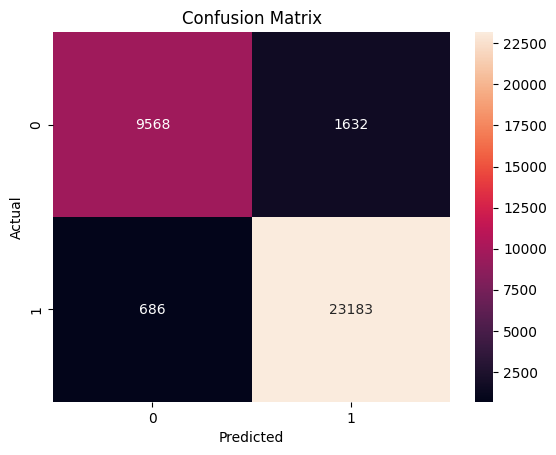

In [ ]:
cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## CELL 12: ROC Curve

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step


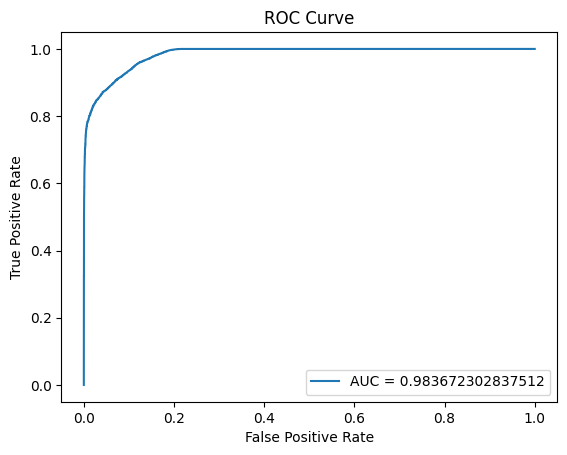

AUC: 0.983672302837512


In [ ]:
# Probabilities
y_probs = final_model.predict(X_te)

# ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc)

## CELL 13: Final Comparison

In [ ]:
# Compare baseline vs hybrid
baseline_acc = accuracy_score(y_test, baseline_preds)
hybrid_acc = accuracy_score(y_test, preds)

print("Baseline Accuracy:", baseline_acc)
print("Hybrid Accuracy:", hybrid_acc)

if hybrid_acc > baseline_acc:
    print("Hybrid model improved performance")
else:
    print("No improvement observed")

Baseline Accuracy: 0.935470073284097
Hybrid Accuracy: 0.9339017365764636
No improvement observed
